# STEP 1: IMPORT LIBRARIES AND LOAD THE DATASET

In [1]:
# Import pandas for data handling and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

df = pd.read_csv("Rahul_Patil_20057979_sentinelTests_Dataset.csv")

# Display the first 5 rows of the dataset
print("First 5 rows of the dataset:")
display(df.head())

# Check the number of rows and columns in the dataset
print("Shape of the dataset (rows, columns):")
print(df.shape)

# Display all column names
print("Column names in the dataset:")
print(df.columns.tolist())

First 5 rows of the dataset:


,survtype,countryname,yearweek,pathogen,pathogentype,pathogensubtype,indicator,age,value
0,primary care sentinel,Austria,2026-W07,Influenza,Influenza,total,detections,total,30.0
1,primary care sentinel,Austria,2026-W07,Influenza,Influenza,total,positivity,total,13.9
2,primary care sentinel,Austria,2026-W07,Influenza,Influenza,total,tests,total,216.0
3,primary care sentinel,Austria,2026-W07,Influenza,Influenza A,A (unknown),detections,total,3.0
4,primary care sentinel,Austria,2026-W07,Influenza,Influenza A,A(H1)pdm09,detections,total,12.0


Shape of the dataset (rows, columns):
(52946, 9)
Column names in the dataset:
['survtype', 'countryname', 'yearweek', 'pathogen', 'pathogentype', 'pathogensubtype', 'indicator', 'age', 'value']


# STEP 2: UNDERSTAND DATASET STRUCTURE AND CHECK MISSING VALUES

In [2]:
print("Dataset Information:")
df.info()

print("\n" + "="*60)

# Check the total number of missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

print("\n" + "="*60)

# Check how many unique countries/areas are present
print("Number of unique countries/areas:")
print(df['countryname'].nunique())

print("\nList of countries/areas:")
print(df['countryname'].unique())

print("\n" + "="*60)

# Check how many unique pathogens are present
print("Unique pathogens in the dataset:")
print(df['pathogen'].unique())

print("\n" + "="*60)

# Check how many unique indicators are present
print("Unique indicators in the dataset:")
print(df['indicator'].unique())

print("\n" + "="*60)

# Check how many unique age groups are present
print("Unique age groups in the dataset:")
print(df['age'].unique())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52946 entries, 0 to 52945
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   survtype         52946 non-null  object 
 1   countryname      52946 non-null  object 
 2   yearweek         52946 non-null  object 
 3   pathogen         52946 non-null  object 
 4   pathogentype     52946 non-null  object 
 5   pathogensubtype  50189 non-null  object 
 6   indicator        52946 non-null  object 
 7   age              52946 non-null  object 
 8   value            52946 non-null  float64
dtypes: float64(1), object(8)
memory usage: 3.6+ MB

Missing values in each column:
survtype              0
countryname           0
yearweek              0
pathogen              0
pathogentype          0
pathogensubtype    2757
indicator             0
age                   0
value                 0
dtype: int64

Number of unique countries/areas:
30

List of count

# STEP 3: FILTER THE DATASET FOR SENTINEL + INFLUENZA

In [3]:
# Show all unique values in the surveillance type column
print("Unique values in 'survtype':")
print(df['survtype'].unique())

print("\n" + "="*60)

# Show all unique values in the pathogen column
print("Unique values in 'pathogen':")
print(df['pathogen'].unique())

Unique values in 'survtype':
['primary care sentinel']

Unique values in 'pathogen':
['Influenza' 'RSV' 'SARS-CoV-2']


In [4]:

df_filtered = df.copy()

# Filter the dataset to keep only primary care sentinel records
df_filtered = df_filtered[df_filtered['survtype'] == 'primary care sentinel']

# Filter the dataset to keep only Influenza records
df_filtered = df_filtered[df_filtered['pathogen'] == 'Influenza']

# Display the first 5 rows of the filtered dataset
print("First 5 rows of the filtered dataset:")
display(df_filtered.head())

# Check the size of the filtered dataset
print("Shape of the filtered dataset (rows, columns):")
print(df_filtered.shape)

# Print a separator line for clean output
print("\n" + "="*60)

# Confirm the surveillance type after filtering
print("Unique surveillance types after filtering:")
print(df_filtered['survtype'].unique())

# Print a separator line
print("\n" + "="*60)

# Confirm the pathogen after filtering
print("Unique pathogens after filtering:")
print(df_filtered['pathogen'].unique())

# Print a separator line
print("\n" + "="*60)

# Check the indicators available after filtering
print("Unique indicators in the filtered dataset:")
print(df_filtered['indicator'].unique())

# Print a separator line
print("\n" + "="*60)

# Check the age categories available after filtering
print("Unique age groups in the filtered dataset:")
print(df_filtered['age'].unique())

First 5 rows of the filtered dataset:


,survtype,countryname,yearweek,pathogen,pathogentype,pathogensubtype,indicator,age,value
0,primary care sentinel,Austria,2026-W07,Influenza,Influenza,total,detections,total,30.0
1,primary care sentinel,Austria,2026-W07,Influenza,Influenza,total,positivity,total,13.9
2,primary care sentinel,Austria,2026-W07,Influenza,Influenza,total,tests,total,216.0
3,primary care sentinel,Austria,2026-W07,Influenza,Influenza A,A (unknown),detections,total,3.0
4,primary care sentinel,Austria,2026-W07,Influenza,Influenza A,A(H1)pdm09,detections,total,12.0


Shape of the filtered dataset (rows, columns):
(23472, 9)

Unique surveillance types after filtering:
['primary care sentinel']

Unique pathogens after filtering:
['Influenza']

Unique indicators in the filtered dataset:
['detections' 'positivity' 'tests']

Unique age groups in the filtered dataset:
['total']


# STEP 4: RESHAPE THE DATASET USING THE INDICATOR COLUMN

In [5]:
# We use countryname, yearweek, pathogen, and age as the row identifiers
df_pivot = df_filtered.pivot_table(
    index=['countryname', 'yearweek', 'pathogen', 'age'],
    columns='indicator',
    values='value',
    aggfunc='first'
).reset_index()

# Remove the column index name created by pivot_table
df_pivot.columns.name = None

# Display the first 5 rows of the reshaped dataset
print("First 5 rows of the reshaped dataset:")
display(df_pivot.head())

# Check the shape of the reshaped dataset
print("Shape of the reshaped dataset (rows, columns):")
print(df_pivot.shape)

# Print a separator line
print("\n" + "="*60)

# Show the new column names after reshaping
print("Column names after reshaping:")
print(df_pivot.columns.tolist())

First 5 rows of the reshaped dataset:


,countryname,yearweek,pathogen,age,detections,positivity,tests
0,Austria,2021-W40,Influenza,total,NaN,NaN,83.0
1,Austria,2021-W41,Influenza,total,NaN,NaN,100.0
2,Austria,2021-W42,Influenza,total,NaN,NaN,105.0
3,Austria,2021-W43,Influenza,total,NaN,NaN,68.0
4,Austria,2021-W44,Influenza,total,NaN,NaN,76.0


Shape of the reshaped dataset (rows, columns):
(5944, 7)

Column names after reshaping:
['countryname', 'yearweek', 'pathogen', 'age', 'detections', 'positivity', 'tests']


# STEP 5: CHECK MISSING VALUES AFTER RESHAPING

In [6]:
# Check the total number of missing values in each column
print("Missing values in each column:")
print(df_pivot.isnull().sum())

# Print a separator line for neat output
print("\n" + "="*60)

# Check the percentage of missing values in each column
print("Percentage of missing values in each column:")
print((df_pivot.isnull().sum() / len(df_pivot)) * 100)

# Print a separator line
print("\n" + "="*60)

# Display rows where at least one of the key indicator columns is missing
print("Sample rows with missing values in tests, detections, or positivity:")
display(df_pivot[df_pivot[['tests', 'detections', 'positivity']].isnull().any(axis=1)].head(10))

Missing values in each column:
countryname       0
yearweek          0
pathogen          0
age               0
detections      826
positivity     1360
tests             0
dtype: int64

Percentage of missing values in each column:
countryname     0.000000
yearweek        0.000000
pathogen        0.000000
age             0.000000
detections     13.896366
positivity     22.880215
tests           0.000000
dtype: float64

Sample rows with missing values in tests, detections, or positivity:


,countryname,yearweek,pathogen,age,detections,positivity,tests
0,Austria,2021-W40,Influenza,total,NaN,NaN,83.0
1,Austria,2021-W41,Influenza,total,NaN,NaN,100.0
2,Austria,2021-W42,Influenza,total,NaN,NaN,105.0
3,Austria,2021-W43,Influenza,total,NaN,NaN,68.0
4,Austria,2021-W44,Influenza,total,NaN,NaN,76.0
5,Austria,2021-W45,Influenza,total,NaN,NaN,197.0
6,Austria,2021-W46,Influenza,total,NaN,NaN,235.0
7,Austria,2021-W47,Influenza,total,NaN,NaN,191.0
8,Austria,2021-W48,Influenza,total,NaN,NaN,129.0
9,Austria,2021-W49,Influenza,total,NaN,NaN,58.0


# STEP 6: HANDLE MISSING VALUES IN DETECTIONS AND POSITIVITY

In [7]:

df_clean = df_pivot.copy()

# Check how many positivity values are missing before calculation
print("Missing positivity values before calculation:")
print(df_clean['positivity'].isnull().sum())

print("\n" + "="*60)

# Calculate positivity only where:
# 1. positivity is missing
# 2. detections is available
# 3. tests is greater than 0
# Formula used: positivity = (detections / tests) * 100
df_clean.loc[
    (df_clean['positivity'].isnull()) &
    (df_clean['detections'].notnull()) &
    (df_clean['tests'] > 0),
    'positivity'
] = (df_clean['detections'] / df_clean['tests']) * 100

# Check how many positivity values are still missing after calculation
print("Missing positivity values after calculation:")
print(df_clean['positivity'].isnull().sum())

print("\n" + "="*60)

# Check how many detections values are still missing
print("Missing detections values before dropping rows:")
print(df_clean['detections'].isnull().sum())

print("\n" + "="*60)

# Drop rows where detections or positivity is still missing
df_clean = df_clean.dropna(subset=['detections', 'positivity'])

# Reset the index after removing rows
df_clean = df_clean.reset_index(drop=True)

# Check the shape of the cleaned dataset
print("Shape of the cleaned dataset after removing missing values:")
print(df_clean.shape)

print("\n" + "="*60)

# Check missing values again in the cleaned dataset
print("Missing values in the cleaned dataset:")
print(df_clean[['tests', 'detections', 'positivity']].isnull().sum())

print("\n" + "="*60)

# Display the first 5 rows of the cleaned dataset
print("First 5 rows of the cleaned dataset:")
display(df_clean.head())

Missing positivity values before calculation:
1360

Missing positivity values after calculation:
1360

Missing detections values before dropping rows:
826

Shape of the cleaned dataset after removing missing values:
(4584, 7)

Missing values in the cleaned dataset:
tests         0
detections    0
positivity    0
dtype: int64

First 5 rows of the cleaned dataset:


,countryname,yearweek,pathogen,age,detections,positivity,tests
0,Austria,2021-W50,Influenza,total,1.0,1.4,70.0
1,Austria,2022-W01,Influenza,total,3.0,3.9,76.0
2,Austria,2022-W02,Influenza,total,3.0,2.0,152.0
3,Austria,2022-W03,Influenza,total,4.0,2.1,188.0
4,Austria,2022-W04,Influenza,total,5.0,2.5,199.0


# STEP 7: CREATE PROPER TIME FEATURES FROM THE YEARWEEK COLUMN

In [8]:

df_time = df_clean.copy()

# Extract the year from the 'yearweek' column
df_time['year'] = df_time['yearweek'].str.extract(r'(\d{4})')

# Extract the week number from the 'yearweek' column
df_time['week'] = df_time['yearweek'].str.extract(r'W(\d{2})')

# Convert year and week into integer format
df_time['year'] = df_time['year'].astype(int)
df_time['week'] = df_time['week'].astype(int)

# Create a proper date column using ISO year-week format
df_time['week_start_date'] = pd.to_datetime(
    df_time['year'].astype(str) + '-W' + df_time['week'].astype(str).str.zfill(2) + '-1',
    format='%G-W%V-%u',
    errors='coerce'
)

# Sort the dataset by country and week_start_date
df_time = df_time.sort_values(by=['countryname', 'week_start_date']).reset_index(drop=True)

# Display the first 10 rows to inspect the new time features
print("First 10 rows after creating time features:")
display(df_time[['countryname', 'yearweek', 'year', 'week', 'week_start_date']].head(10))

# Print a separator line
print("\n" + "="*60)

# Check the data types of the new columns
print("Data types of the new time-related columns:")
print(df_time[['year', 'week', 'week_start_date']].dtypes)

# Print a separator line
print("\n" + "="*60)

# Check whether any week_start_date values failed to convert
print("Missing values in week_start_date:")
print(df_time['week_start_date'].isnull().sum())

# Print a separator line
print("\n" + "="*60)

# Check the final shape of the dataset after time feature creation
print("Shape of the dataset after adding time features:")
print(df_time.shape)

First 10 rows after creating time features:


,countryname,yearweek,year,week,week_start_date
0,Austria,2021-W50,2021,50,2021-12-13
1,Austria,2022-W01,2022,1,2022-01-03
2,Austria,2022-W02,2022,2,2022-01-10
3,Austria,2022-W03,2022,3,2022-01-17
4,Austria,2022-W04,2022,4,2022-01-24
5,Austria,2022-W05,2022,5,2022-01-31
6,Austria,2022-W06,2022,6,2022-02-07
7,Austria,2022-W07,2022,7,2022-02-14
8,Austria,2022-W08,2022,8,2022-02-21
9,Austria,2022-W09,2022,9,2022-02-28



Data types of the new time-related columns:
year                        int64
week                        int64
week_start_date    datetime64[ns]
dtype: object

Missing values in week_start_date:
0

Shape of the dataset after adding time features:
(4584, 10)


# STEP 8: CREATE LAG FEATURES AND CHANGE-BASED FEATURES

In [9]:

df_features = df_time.copy()

# Create lag-1 feature for positivity
df_features['positivity_lag1'] = df_features.groupby('countryname')['positivity'].shift(1)

# Create lag-1 feature for detections
df_features['detections_lag1'] = df_features.groupby('countryname')['detections'].shift(1)

# Create lag-1 feature for tests
df_features['tests_lag1'] = df_features.groupby('countryname')['tests'].shift(1)

# Create change in positivity from the previous week
# Current positivity minus previous week's positivity
df_features['positivity_change'] = df_features['positivity'] - df_features['positivity_lag1']

# Create change in detections from the previous week
# Current detections minus previous week's detections
df_features['detections_change'] = df_features['detections'] - df_features['detections_lag1']

# Display the first 10 rows with the new features
print("First 10 rows after creating lag and change-based features:")
display(df_features[
    ['countryname', 'yearweek', 'positivity', 'positivity_lag1', 'positivity_change',
     'detections', 'detections_lag1', 'detections_change', 'tests', 'tests_lag1']
].head(10))

# Print a separator line
print("\n" + "="*60)

# Check missing values in the newly created lag features
print("Missing values in lag and change-based features:")
print(df_features[
    ['positivity_lag1', 'detections_lag1', 'tests_lag1', 'positivity_change', 'detections_change']
].isnull().sum())

# Print a separator line
print("\n" + "="*60)

# Check the shape of the dataset after adding lag features
print("Shape of the dataset after adding lag features:")
print(df_features.shape)

First 10 rows after creating lag and change-based features:


,countryname,yearweek,positivity,positivity_lag1,positivity_change,detections,detections_lag1,detections_change,tests,tests_lag1
0,Austria,2021-W50,1.4,NaN,NaN,1.0,NaN,NaN,70.0,NaN
1,Austria,2022-W01,3.9,1.4,2.5,3.0,1.0,2.0,76.0,70.0
2,Austria,2022-W02,2.0,3.9,-1.9,3.0,3.0,0.0,152.0,76.0
3,Austria,2022-W03,2.1,2.0,0.1,4.0,3.0,1.0,188.0,152.0
4,Austria,2022-W04,2.5,2.1,0.4,5.0,4.0,1.0,199.0,188.0
5,Austria,2022-W05,2.2,2.5,-0.3,4.0,5.0,-1.0,186.0,199.0
6,Austria,2022-W06,0.5,2.2,-1.7,1.0,4.0,-3.0,206.0,186.0
7,Austria,2022-W07,2.2,0.5,1.7,3.0,1.0,2.0,139.0,206.0
8,Austria,2022-W08,3.1,2.2,0.9,4.0,3.0,1.0,131.0,139.0
9,Austria,2022-W09,4.5,3.1,1.4,7.0,4.0,3.0,154.0,131.0



Missing values in lag and change-based features:
positivity_lag1      29
detections_lag1      29
tests_lag1           29
positivity_change    29
detections_change    29
dtype: int64

Shape of the dataset after adding lag features:
(4584, 15)


# STEP 9: CREATE 3-WEEK ROLLING AVERAGE FEATURES

In [10]:

df_features2 = df_features.copy()

# Create 3-week rolling average for positivity for each country
df_features2['positivity_roll3'] = (
    df_features2.groupby('countryname')['positivity']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

# Create 3-week rolling average for detections for each country
df_features2['detections_roll3'] = (
    df_features2.groupby('countryname')['detections']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

# Create 3-week rolling average for tests for each country
df_features2['tests_roll3'] = (
    df_features2.groupby('countryname')['tests']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

# Display the first 10 rows with the new rolling features
print("First 10 rows after creating rolling average features:")
display(
    df_features2[
        ['countryname', 'yearweek', 'positivity', 'positivity_roll3',
         'detections', 'detections_roll3', 'tests', 'tests_roll3']
    ].head(10)
)

# Print a separator line
print("\n" + "="*60)

# Check missing values in the rolling average features
print("Missing values in rolling average features:")
print(
    df_features2[['positivity_roll3', 'detections_roll3', 'tests_roll3']]
    .isnull()
    .sum()
)

# Print a separator line
print("\n" + "="*60)

# Check the shape of the dataset after adding rolling features
print("Shape of the dataset after adding rolling average features:")
print(df_features2.shape)

First 10 rows after creating rolling average features:


,countryname,yearweek,positivity,positivity_roll3,detections,detections_roll3,tests,tests_roll3
0,Austria,2021-W50,1.4,1.400000,1.0,1.000000,70.0,70.000000
1,Austria,2022-W01,3.9,2.650000,3.0,2.000000,76.0,73.000000
2,Austria,2022-W02,2.0,2.433333,3.0,2.333333,152.0,99.333333
3,Austria,2022-W03,2.1,2.666667,4.0,3.333333,188.0,138.666667
4,Austria,2022-W04,2.5,2.200000,5.0,4.000000,199.0,179.666667
5,Austria,2022-W05,2.2,2.266667,4.0,4.333333,186.0,191.000000
6,Austria,2022-W06,0.5,1.733333,1.0,3.333333,206.0,197.000000
7,Austria,2022-W07,2.2,1.633333,3.0,2.666667,139.0,177.000000
8,Austria,2022-W08,3.1,1.933333,4.0,2.666667,131.0,158.666667
9,Austria,2022-W09,4.5,3.266667,7.0,4.666667,154.0,141.333333



Missing values in rolling average features:
positivity_roll3    0
detections_roll3    0
tests_roll3         0
dtype: int64

Shape of the dataset after adding rolling average features:
(4584, 18)


# STEP 10: CREATE THE TARGET VARIABLE FOR NEXT-WEEK OUTBREAK

In [11]:

df_model = df_features2.copy()

# Create the current outbreak flag
# If positivity is 10 or more, mark it as outbreak = 1
# Otherwise, mark it as non-outbreak = 0
df_model['outbreak_current'] = (df_model['positivity'] >= 10).astype(int)

# Create the next-week outbreak target for each country

df_model['outbreak_next_week'] = (
    df_model.groupby('countryname')['outbreak_current'].shift(-1)
)

# Check the first 10 rows to understand how the target was created
print("First 10 rows showing current and next-week outbreak flags:")
display(
    df_model[
        ['countryname', 'yearweek', 'positivity', 'outbreak_current', 'outbreak_next_week']
    ].head(10)
)

# Print a separator line for cleaner output
print("\n" + "="*60)

# Check missing values in the target column
# The last week of each country will usually have missing next-week target
print("Missing values in 'outbreak_next_week':")
print(df_model['outbreak_next_week'].isnull().sum())

# Print a separator line
print("\n" + "="*60)

# Remove rows where next-week outbreak target is missing
df_model = df_model.dropna(subset=['outbreak_next_week']).reset_index(drop=True)

# Convert the target column to integer format
df_model['outbreak_next_week'] = df_model['outbreak_next_week'].astype(int)

# Check class distribution of the final target variable
print("Class distribution of next-week outbreak target:")
print(df_model['outbreak_next_week'].value_counts())

# Print a separator line
print("\n" + "="*60)

# Check the shape of the final modelling dataset
print("Shape of the modelling dataset after target creation:")
print(df_model.shape)

First 10 rows showing current and next-week outbreak flags:


,countryname,yearweek,positivity,outbreak_current,outbreak_next_week
0,Austria,2021-W50,1.4,0,0.0
1,Austria,2022-W01,3.9,0,0.0
2,Austria,2022-W02,2.0,0,0.0
3,Austria,2022-W03,2.1,0,0.0
4,Austria,2022-W04,2.5,0,0.0
5,Austria,2022-W05,2.2,0,0.0
6,Austria,2022-W06,0.5,0,0.0
7,Austria,2022-W07,2.2,0,0.0
8,Austria,2022-W08,3.1,0,0.0
9,Austria,2022-W09,4.5,0,0.0



Missing values in 'outbreak_next_week':
29

Class distribution of next-week outbreak target:
outbreak_next_week
0    2611
1    1944
Name: count, dtype: int64

Shape of the modelling dataset after target creation:
(4555, 20)


# STEP 11: PREPARE THE FINAL FEATURE SET FOR MODELLING

In [12]:

df_final = df_model.copy()

# Select the final feature columns for machine learning
# These features are based on current values, lag values, change values,
# rolling averages, and basic time information
feature_columns = [
    'tests',
    'detections',
    'positivity',
    'year',
    'week',
    'positivity_lag1',
    'detections_lag1',
    'tests_lag1',
    'positivity_change',
    'detections_change',
    'positivity_roll3',
    'detections_roll3',
    'tests_roll3'
]

# Define the target column
target_column = 'outbreak_next_week'

# Check missing values in the selected feature columns before dropping rows
print("Missing values in selected feature columns before cleaning:")
print(df_final[feature_columns].isnull().sum())

# Print a separator line
print("\n" + "="*60)

# Remove rows with missing values in any selected feature column
# These rows usually occur at the first available week for each country
df_final = df_final.dropna(subset=feature_columns).reset_index(drop=True)

# Check missing values again after cleaning
print("Missing values in selected feature columns after cleaning:")
print(df_final[feature_columns].isnull().sum())

# Print a separator line
print("\n" + "="*60)

# Display the first 5 rows of the final modelling dataset
print("First 5 rows of the final modelling dataset:")
display(df_final[feature_columns + [target_column]].head())

# Print a separator line
print("\n" + "="*60)

# Check the final shape of the modelling dataset
print("Final shape of the modelling dataset:")
print(df_final.shape)

# Print a separator line
print("\n" + "="*60)

# Check the class distribution again after removing lag-related missing rows
print("Class distribution after final cleaning:")
print(df_final[target_column].value_counts())

Missing values in selected feature columns before cleaning:
tests                 0
detections            0
positivity            0
year                  0
week                  0
positivity_lag1      29
detections_lag1      29
tests_lag1           29
positivity_change    29
detections_change    29
positivity_roll3      0
detections_roll3      0
tests_roll3           0
dtype: int64

Missing values in selected feature columns after cleaning:
tests                0
detections           0
positivity           0
year                 0
week                 0
positivity_lag1      0
detections_lag1      0
tests_lag1           0
positivity_change    0
detections_change    0
positivity_roll3     0
detections_roll3     0
tests_roll3          0
dtype: int64

First 5 rows of the final modelling dataset:


,tests,detections,positivity,year,week,positivity_lag1,detections_lag1,tests_lag1,positivity_change,detections_change,positivity_roll3,detections_roll3,tests_roll3,outbreak_next_week
0,76.0,3.0,3.9,2022,1,1.4,1.0,70.0,2.5,2.0,2.650000,2.000000,73.000000,0
1,152.0,3.0,2.0,2022,2,3.9,3.0,76.0,-1.9,0.0,2.433333,2.333333,99.333333,0
2,188.0,4.0,2.1,2022,3,2.0,3.0,152.0,0.1,1.0,2.666667,3.333333,138.666667,0
3,199.0,5.0,2.5,2022,4,2.1,4.0,188.0,0.4,1.0,2.200000,4.000000,179.666667,0
4,186.0,4.0,2.2,2022,5,2.5,5.0,199.0,-0.3,-1.0,2.266667,4.333333,191.000000,0



Final shape of the modelling dataset:
(4526, 20)

Class distribution after final cleaning:
outbreak_next_week
0    2585
1    1941
Name: count, dtype: int64


# STEP 12: CREATE A CLEANER CHRONOLOGICAL SPLIT BY UNIQUE WEEK

In [13]:

df_split = df_final.copy()

# Sort the dataset by week_start_date
df_split = df_split.sort_values(by='week_start_date').reset_index(drop=True)

# Define the feature columns
feature_columns = [
    'tests',
    'detections',
    'positivity',
    'year',
    'week',
    'positivity_lag1',
    'detections_lag1',
    'tests_lag1',
    'positivity_change',
    'detections_change',
    'positivity_roll3',
    'detections_roll3',
    'tests_roll3'
]

# Define the target column
target_column = 'outbreak_next_week'

# Get the sorted unique week_start_date values
unique_weeks = sorted(df_split['week_start_date'].unique())

# Use 80% of unique weeks for training and 20% for testing
split_week_index = int(len(unique_weeks) * 0.8)

# Identify the last training week and first testing week
train_weeks = unique_weeks[:split_week_index]
test_weeks = unique_weeks[split_week_index:]

# Create train and test datasets based on full weeks
train_data = df_split[df_split['week_start_date'].isin(train_weeks)].copy()
test_data = df_split[df_split['week_start_date'].isin(test_weeks)].copy()

# Create X and y sets
X_train = train_data[feature_columns]
X_test = test_data[feature_columns]
y_train = train_data[target_column]
y_test = test_data[target_column]

# Print shapes
print("Training feature set shape:")
print(X_train.shape)

print("\n" + "="*60)

print("Testing feature set shape:")
print(X_test.shape)

print("\n" + "="*60)

print("Training target set shape:")
print(y_train.shape)

print("\n" + "="*60)

print("Testing target set shape:")
print(y_test.shape)

print("\n" + "="*60)

# Print time periods
print("Training period:")
print(train_data['week_start_date'].min(), "to", train_data['week_start_date'].max())

print("\n" + "="*60)

print("Testing period:")
print(test_data['week_start_date'].min(), "to", test_data['week_start_date'].max())

print("\n" + "="*60)

# Print class distributions
print("Class distribution in training target:")
print(y_train.value_counts())

print("\n" + "="*60)

print("Class distribution in testing target:")
print(y_test.value_counts())

Training feature set shape:
(3551, 13)

Testing feature set shape:
(975, 13)

Training target set shape:
(3551,)

Testing target set shape:
(975,)

Training period:
2021-06-28 00:00:00 to 2025-02-24 00:00:00

Testing period:
2025-03-03 00:00:00 to 2026-02-02 00:00:00

Class distribution in training target:
outbreak_next_week
0    2020
1    1531
Name: count, dtype: int64

Class distribution in testing target:
outbreak_next_week
0    565
1    410
Name: count, dtype: int64


#STEP 13: TRAIN AND EVALUATE THE TUNED LOGISTIC REGRESSION MODEL

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Reset index to make row-based CV splits clean and safe
train_data = train_data.sort_values(by='week_start_date').reset_index(drop=True)
test_data = test_data.sort_values(by='week_start_date').reset_index(drop=True)

# Recreate X and y
X_train = train_data[feature_columns].copy()
X_test = test_data[feature_columns].copy()
y_train = train_data[target_column].copy()
y_test = test_data[target_column].copy()

# Create time-series cross-validation splits using full weeks
unique_train_weeks = np.array(sorted(train_data['week_start_date'].unique()))
tscv = TimeSeriesSplit(n_splits=5)

cv_splits = []

for train_week_idx, val_week_idx in tscv.split(unique_train_weeks):
    train_weeks_cv = unique_train_weeks[train_week_idx]
    val_weeks_cv = unique_train_weeks[val_week_idx]

    train_rows = train_data.index[train_data['week_start_date'].isin(train_weeks_cv)].to_numpy()
    val_rows = train_data.index[train_data['week_start_date'].isin(val_weeks_cv)].to_numpy()

    cv_splits.append((train_rows, val_rows))

print("Number of time-based CV splits created:")
print(len(cv_splits))

print("\n" + "="*60)

# Use F1-score as the tuning metric
scoring_metric = 'f1'

# Create a helper function to evaluate each tuned model on the test set
def evaluate_tuned_model(model_name, fitted_model, X_test, y_test):
    # Predict class labels
    y_pred = fitted_model.predict(X_test)

    # Predict probabilities for ROC-AUC
    y_prob = fitted_model.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Print the performance
    print(f"{model_name} Performance:")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")

    print("\n" + "="*60)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\n" + "="*60)

    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return y_pred, y_prob, accuracy, precision, recall, f1, roc_auc

# Create a pipeline for Logistic Regression
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

# Define the hyperparameter grid
logreg_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs'],
    'model__class_weight': [None, 'balanced']
}

# Apply Grid Search with time-series cross-validation
logreg_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_param_grid,
    scoring=scoring_metric,
    cv=cv_splits,
    n_jobs=-1,
    verbose=1
)

# Train the tuned Logistic Regression model
logreg_search.fit(X_train, y_train)

# Get the best tuned model
logreg_pipeline = logreg_search.best_estimator_

print("Best Logistic Regression Parameters:")
print(logreg_search.best_params_)

print("\n" + "="*60)

print("Best Cross-Validation F1-Score:")
print(round(logreg_search.best_score_, 4))

print("\n" + "="*60)

# Evaluate on the test set
y_pred_logreg, y_prob_logreg, logreg_accuracy, logreg_precision, logreg_recall, logreg_f1, logreg_roc_auc = evaluate_tuned_model(
    "Logistic Regression",
    logreg_pipeline,
    X_test,
    y_test
)

# Store the best CV score
logreg_cv_f1 = logreg_search.best_score_

Number of time-based CV splits created:
5

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression Parameters:
{'model__C': 0.1, 'model__class_weight': None, 'model__solver': 'lbfgs'}

Best Cross-Validation F1-Score:
0.777

Logistic Regression Performance:
Accuracy  : 0.8646
Precision : 0.8697
Recall    : 0.7976
F1-Score  : 0.8321
ROC-AUC   : 0.9181

Confusion Matrix:
[[516  49]
 [ 83 327]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.89       565
           1       0.87      0.80      0.83       410

    accuracy                           0.86       975
   macro avg       0.87      0.86      0.86       975
weighted avg       0.86      0.86      0.86       975



#STEP 14: TRAIN AND EVALUATE THE TUNED DECISION TREE MODEL

In [15]:
# Create the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Define the hyperparameter search space
dt_param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

# Apply Randomized Search with time-series cross-validation
dt_search = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=dt_param_dist,
    n_iter=20,
    scoring=scoring_metric,
    cv=cv_splits,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Train the tuned Decision Tree model
dt_search.fit(X_train, y_train)

# Get the best tuned model
dt_model = dt_search.best_estimator_

print("Best Decision Tree Parameters:")
print(dt_search.best_params_)

print("\n" + "="*60)

print("Best Cross-Validation F1-Score:")
print(round(dt_search.best_score_, 4))

print("\n" + "="*60)

# Evaluate on the test set
y_pred_dt, y_prob_dt, dt_accuracy, dt_precision, dt_recall, dt_f1, dt_roc_auc = evaluate_tuned_model(
    "Decision Tree",
    dt_model,
    X_test,
    y_test
)

# Store the best CV score
dt_cv_f1 = dt_search.best_score_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Decision Tree Parameters:
{'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 3, 'criterion': 'gini', 'class_weight': 'balanced'}

Best Cross-Validation F1-Score:
0.8005

Decision Tree Performance:
Accuracy  : 0.8697
Precision : 0.8329
Recall    : 0.8634
F1-Score  : 0.8479
ROC-AUC   : 0.9139

Confusion Matrix:
[[494  71]
 [ 56 354]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       565
           1       0.83      0.86      0.85       410

    accuracy                           0.87       975
   macro avg       0.87      0.87      0.87       975
weighted avg       0.87      0.87      0.87       975



#STEP 15: TRAIN AND EVALUATE THE TUNED RANDOM FOREST MODEL

In [16]:
# Create the Random Forest model
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Define the hyperparameter search space
rf_param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced']
}

# Apply Randomized Search with time-series cross-validation
rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring=scoring_metric,
    cv=cv_splits,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Train the tuned Random Forest model
rf_search.fit(X_train, y_train)

# Get the best tuned model
rf_model = rf_search.best_estimator_

print("Best Random Forest Parameters:")
print(rf_search.best_params_)

print("\n" + "="*60)

print("Best Cross-Validation F1-Score:")
print(round(rf_search.best_score_, 4))

print("\n" + "="*60)

# Evaluate on the test set
y_pred_rf, y_prob_rf, rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc = evaluate_tuned_model(
    "Random Forest",
    rf_model,
    X_test,
    y_test
)

# Store the best CV score
rf_cv_f1 = rf_search.best_score_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Random Forest Parameters:
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 20, 'class_weight': None}

Best Cross-Validation F1-Score:
0.8249

Random Forest Performance:
Accuracy  : 0.9026
Precision : 0.9070
Recall    : 0.8561
F1-Score  : 0.8808
ROC-AUC   : 0.9444

Confusion Matrix:
[[529  36]
 [ 59 351]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       565
           1       0.91      0.86      0.88       410

    accuracy                           0.90       975
   macro avg       0.90      0.90      0.90       975
weighted avg       0.90      0.90      0.90       975



#STEP 16: TRAIN AND EVALUATE THE TUNED SUPPORT VECTOR MACHINE MODEL

In [17]:
# Create a pipeline for Support Vector Machine
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(probability=True, random_state=42))
])

# Define the hyperparameter search space
svm_param_dist = {
    'model__C': [0.1, 1, 10, 50],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 0.01, 0.1, 1],
    'model__class_weight': [None, 'balanced']
}

# Apply Randomized Search with time-series cross-validation
svm_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_param_dist,
    n_iter=12,
    scoring=scoring_metric,
    cv=cv_splits,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Train the tuned SVM model
svm_search.fit(X_train, y_train)

# Get the best tuned model
svm_pipeline = svm_search.best_estimator_

print("Best SVM Parameters:")
print(svm_search.best_params_)

print("\n" + "="*60)

print("Best Cross-Validation F1-Score:")
print(round(svm_search.best_score_, 4))

print("\n" + "="*60)

# Evaluate on the test set
y_pred_svm, y_prob_svm, svm_accuracy, svm_precision, svm_recall, svm_f1, svm_roc_auc = evaluate_tuned_model(
    "Support Vector Machine",
    svm_pipeline,
    X_test,
    y_test
)

# Store the best CV score
svm_cv_f1 = svm_search.best_score_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best SVM Parameters:
{'model__kernel': 'rbf', 'model__gamma': 'scale', 'model__class_weight': 'balanced', 'model__C': 1}

Best Cross-Validation F1-Score:
0.7917

Support Vector Machine Performance:
Accuracy  : 0.8821
Precision : 0.8554
Recall    : 0.8659
F1-Score  : 0.8606
ROC-AUC   : 0.9305

Confusion Matrix:
[[505  60]
 [ 55 355]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       565
           1       0.86      0.87      0.86       410

    accuracy                           0.88       975
   macro avg       0.88      0.88      0.88       975
weighted avg       0.88      0.88      0.88       975



#STEP 17: TRAIN AND EVALUATE THE TUNED K-NEAREST NEIGHBOURS MODEL

In [18]:
# Create a pipeline for K-Nearest Neighbours
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

# Define the hyperparameter grid
knn_param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

# Apply Grid Search with time-series cross-validation
knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring=scoring_metric,
    cv=cv_splits,
    n_jobs=-1,
    verbose=1
)

# Train the tuned KNN model
knn_search.fit(X_train, y_train)

# Get the best tuned model
knn_pipeline = knn_search.best_estimator_

print("Best KNN Parameters:")
print(knn_search.best_params_)

print("\n" + "="*60)

print("Best Cross-Validation F1-Score:")
print(round(knn_search.best_score_, 4))

print("\n" + "="*60)

# Evaluate on the test set
y_pred_knn, y_prob_knn, knn_accuracy, knn_precision, knn_recall, knn_f1, knn_roc_auc = evaluate_tuned_model(
    "K-Nearest Neighbours",
    knn_pipeline,
    X_test,
    y_test
)

# Store the best CV score
knn_cv_f1 = knn_search.best_score_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best KNN Parameters:
{'model__n_neighbors': 7, 'model__p': 2, 'model__weights': 'distance'}

Best Cross-Validation F1-Score:
0.8036

K-Nearest Neighbours Performance:
Accuracy  : 0.8903
Precision : 0.8741
Recall    : 0.8634
F1-Score  : 0.8687
ROC-AUC   : 0.9200

Confusion Matrix:
[[514  51]
 [ 56 354]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       565
           1       0.87      0.86      0.87       410

    accuracy                           0.89       975
   macro avg       0.89      0.89      0.89       975
weighted avg       0.89      0.89      0.89       975



#STEP 18: CREATE A FINAL MODEL COMPARISON TABLE

In [19]:
# Create a dictionary containing the cross-validation and test results of all models
model_results = {
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Support Vector Machine',
        'K-Nearest Neighbours'
    ],
    'Best_CV_F1': [
        logreg_cv_f1,
        dt_cv_f1,
        rf_cv_f1,
        svm_cv_f1,
        knn_cv_f1
    ],
    'Accuracy': [
        logreg_accuracy,
        dt_accuracy,
        rf_accuracy,
        svm_accuracy,
        knn_accuracy
    ],
    'Precision': [
        logreg_precision,
        dt_precision,
        rf_precision,
        svm_precision,
        knn_precision
    ],
    'Recall': [
        logreg_recall,
        dt_recall,
        rf_recall,
        svm_recall,
        knn_recall
    ],
    'F1_Score': [
        logreg_f1,
        dt_f1,
        rf_f1,
        svm_f1,
        knn_f1
    ],
    'ROC_AUC': [
        logreg_roc_auc,
        dt_roc_auc,
        rf_roc_auc,
        svm_roc_auc,
        knn_roc_auc
    ]
}

# Convert the dictionary into a DataFrame
comparison_df = pd.DataFrame(model_results)

# Round values for neat display
comparison_df = comparison_df.round(4)

# Sort by F1-score in descending order
comparison_df = comparison_df.sort_values(by='F1_Score', ascending=False).reset_index(drop=True)

# Display the comparison table
print("Final Model Comparison Table:")
display(comparison_df)

print("\n" + "="*60)

# Identify the best model based on the highest F1-score
best_model_row = comparison_df.loc[comparison_df['F1_Score'].idxmax()]

print("Best model based on F1-score:")
print(best_model_row)

Final Model Comparison Table:


,Model,Best_CV_F1,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Random Forest,0.8249,0.9026,0.9070,0.8561,0.8808,0.9444
1,K-Nearest Neighbours,0.8036,0.8903,0.8741,0.8634,0.8687,0.9200
2,Support Vector Machine,0.7917,0.8821,0.8554,0.8659,0.8606,0.9305
3,Decision Tree,0.8005,0.8697,0.8329,0.8634,0.8479,0.9139
4,Logistic Regression,0.7770,0.8646,0.8697,0.7976,0.8321,0.9181



Best model based on F1-score:
Model         Random Forest
Best_CV_F1           0.8249
Accuracy             0.9026
Precision             0.907
Recall               0.8561
F1_Score             0.8808
ROC_AUC              0.9444
Name: 0, dtype: object


#STEP 19: EXTRACT FEATURE IMPORTANCE FROM TUNED RANDOM FOREST

In [20]:
# Create a DataFrame showing the importance of each feature
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
})

# Sort the features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# Round the importance values
feature_importance_df['Importance'] = feature_importance_df['Importance'].round(4)

# Display the feature importance table
print("Feature Importance from Tuned Random Forest:")
display(feature_importance_df)

Feature Importance from Tuned Random Forest:


,Feature,Importance
0,positivity,0.6943
1,week,0.0691
2,positivity_roll3,0.0555
3,detections_roll3,0.0516
4,tests_roll3,0.0199
5,tests_lag1,0.0195
6,tests,0.0191
7,positivity_lag1,0.0184
8,positivity_change,0.0163
9,year,0.0111


#STEP 20: PLOT TUNED RANDOM FOREST FEATURE IMPORTANCE

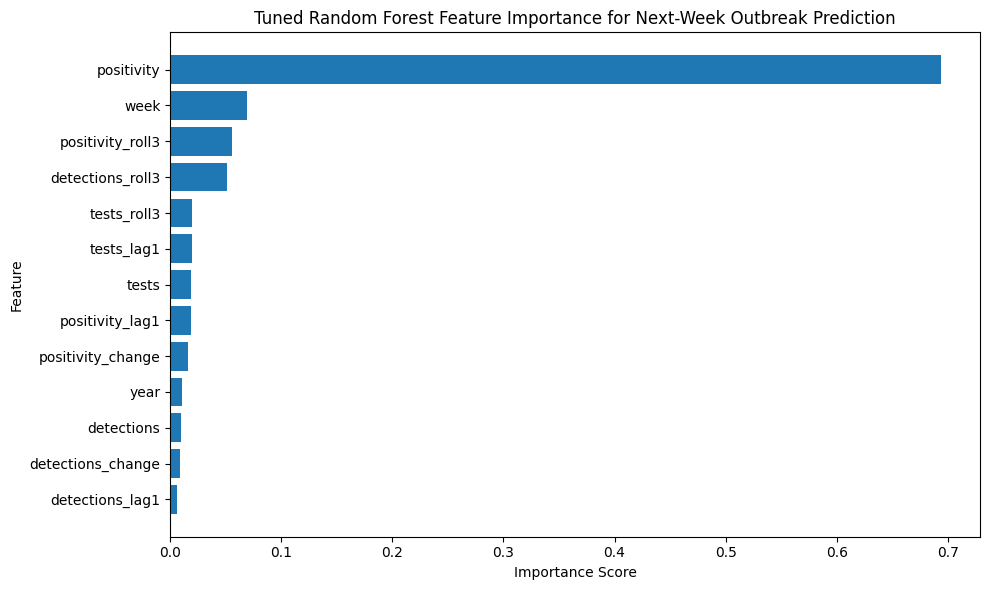

In [21]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Create the figure
plt.figure(figsize=(10, 6))

# Plot a horizontal bar chart
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])

# Invert the y-axis so the most important feature appears at the top
plt.gca().invert_yaxis()

# Add chart title and axis labels
plt.title("Tuned Random Forest Feature Importance for Next-Week Outbreak Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

# Improve layout
plt.tight_layout()

# Show the chart
plt.show()

STEP 21: PLOT THE TUNED RANDOM FOREST CONFUSION MATRIX

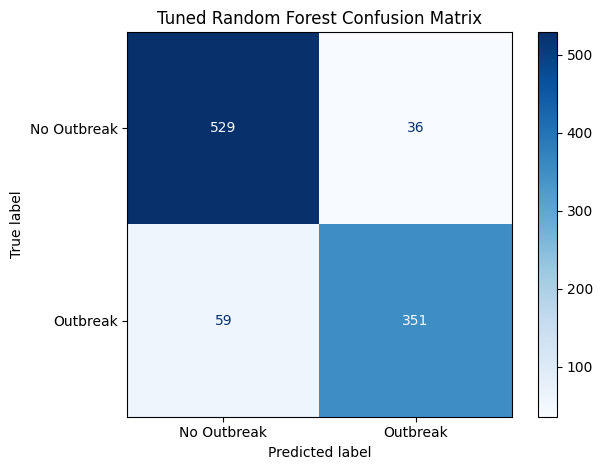

In [22]:
# Import the required tool for confusion matrix plotting
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the confusion matrix display
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Outbreak', 'Outbreak'],
    cmap='Blues',
    values_format='d'
)

# Set the chart title
plt.title("Tuned Random Forest Confusion Matrix")

# Adjust layout
plt.tight_layout()

# Show the chart
plt.show()

#STEP 22: PLOT ROC CURVES FOR ALL 5 TUNED MODELS

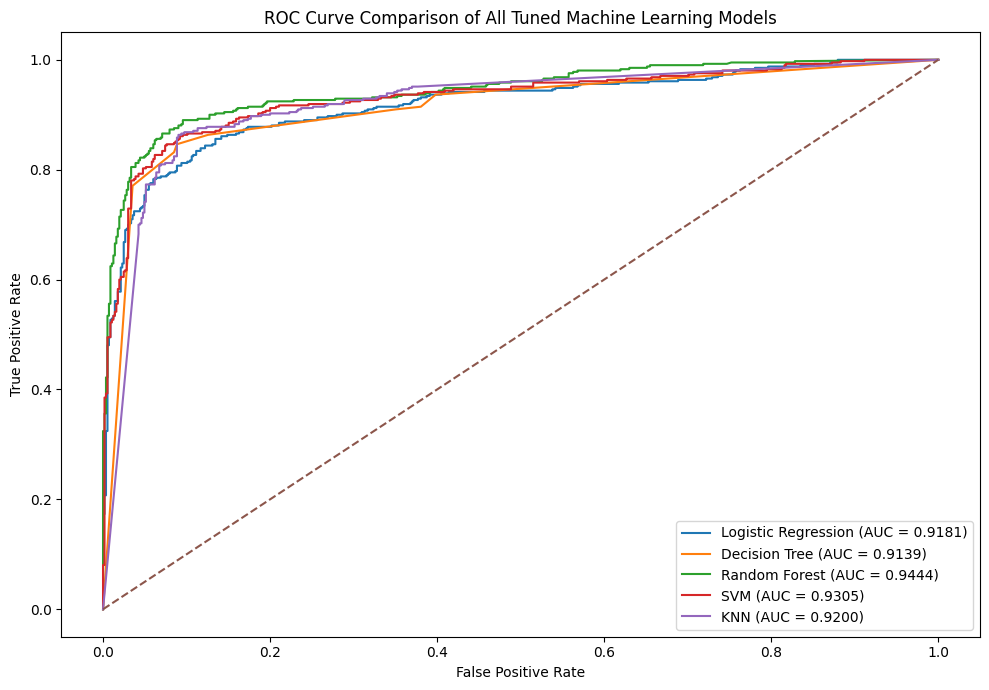

In [23]:
# Import the required tools for ROC curve plotting
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve points for Logistic Regression
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg)

# Calculate ROC curve points for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Calculate ROC curve points for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Calculate ROC curve points for Support Vector Machine
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Calculate ROC curve points for K-Nearest Neighbours
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# Create the ROC curve figure
plt.figure(figsize=(10, 7))

# Plot ROC curves for all tuned models
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {roc_auc_logreg:.4f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.4f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.4f})')

# Plot the diagonal reference line
plt.plot([0, 1], [0, 1], linestyle='--')

# Add title and labels
plt.title('ROC Curve Comparison of All Tuned Machine Learning Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Add legend
plt.legend(loc='lower right')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()